## Aligning PACE and EMIT Data
Adapted from "Projecting & GeoTIFF" tutorial on OB.DAAC's [Help Hub][help-hub] and from LP.DAAC's [VITALS][vitals] "Working with EMIT L2A Reflectance and ECOSTRESS L2 LSTE" tutorial.

Authors: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 03/31/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html
[help-hub]: https://nasa.github.io/oceandata-notebooks/
[vitals]: https://nasa.github.io/VITALS/

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

## Summary
The Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) mission and the Earth Surface Mineral Dust Source Investigation (EMIT) sensor aboard the International Space Station (ISS) both make hyperspectral observations of the Earth's surface. Taking into account their different spectral, spatial, and temporal coverage, these instruments' capabilities are extremely complementary and provide a wealth of new opportunities when used in concert. In this series of tutorials, we will demonstrate how to find, prepare, and use data from both PACE and EMIT together, illustarting each missions' strengths and where they can fill in each others' gaps.

This is the second tutorial in the PACE-EMIT series. This notebook will use the reflectance data downloaded from the first tutorial, `01_Colocate_PACE_EMIT_data`, as well as the `rasterio` and `rioxarray` packages to put PACE Ocean Color Instrument (OCI) and EMIT data on the same grid. We will use tools from LPDAAC's VITALS tutorials to orthorectify the EMIT data, and then place PACE and EMIT granules on a generalized grid using OCI's coarser resolution. We can then compare the data from the two sensors. These techniques will also be integral to our fire analyses in the third tutorial, `03_NBR_with_PACE_EMIT`.

## Learning Objectives

At the end of this notebook, you will know how to:
- Open and orthorectify an EMIT granule
- Open a PACE OCI granule and take it from swath to a defined grid
- Upscale PACE OCI to EMIT resolution

## Contents
1. [Setup](#1.-Setup)
2. [Gridding EMIT Data](#2.-Gridding-EMIT-Data)
3. [Gridding PACE OCI Data](#3.-Gridding-PACE-OCI-Data)
4. [Aligning PACE and EMIT Grids](#4.-Aligning-PACE-and-EMIT-Grids)


## 1. Setup

Begin by importing all of the packages used in this notebook.

In [1]:
import os
import cartopy
import rasterio 
import cf_xarray 
import numpy as np 
import xarray as xr 
import rioxarray as rio
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 
from rasterio.crs import CRS
from rasterio.enums import Resampling
from mpl_toolkits.axes_grid1 import make_axes_locatable

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def plot_features(ax, gridline_alpha=1):
    """
    Function to add gridlines and cartopy features to a figure.
    Args:
        ax - matplotlib Axes object on which to plot the features
        gridline_alpha - fractional opacity of gridlines on the plot. Will also 
             make sure x, y axes are labelled with lon/lats, respectively. 0 will 
             include axes labels but not plot gridlines
    """
    for a in range(len(ax)):
        ax[a].gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=gridline_alpha)
        ax[a].coastlines(linewidth=0.5)
        ax[a].add_feature(cartopy.feature.OCEAN, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAND, edgecolor="w", linewidth=0.01)
        ax[a].add_feature(cartopy.feature.LAKES, edgecolor="w", linewidth=0.01)

In the last notebook, we found and downloaded EMIT and PACE data corresponding to one pre-fire and one post-fire day for the Grampians National Park fire in Victoria, Australia, as one of our eventual goals for the third tutorial notebook is to compute the difference in Normalized Burn Ratio (dNBR) with both of our instruments. 

We'll be using these files for the rest of the tutorials in this series, and so define their paths for this notebook in the cell below. Please change these paths to your own download locations if it differs from those below. 

In [2]:
emit_paths = ["emit_pace/data/EMIT_L2A_RFL_001_20241114T035747_2431902_008.nc",
              "emit_pace/data/EMIT_L2A_RFL_001_20250319T022818_2507801_008.nc",
              "emit_pace/data/EMIT_L2A_MASK_001_20241114T035747_2431902_008.nc",
              "emit_pace/data/EMIT_L2A_MASK_001_20250319T022818_2507801_008.nc"]
oci_paths = ["emit_pace/data/PACE_OCI.20241114T035224.L2.SFREFL.V3_1.nc",
             "emit_pace/data/PACE_OCI.20250319T042120.L2.SFREFL.V3_1.nc"]

If for some reason you need to download these files, uncomment and run the cell below.

In [3]:
# import earthaccess
# earthaccess.login()
# file_urls = [
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20240825T173115_2423811_008/EMIT_L2A_RFL_001_20240825T173115_2423811_008.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20240825T173115_2423811_008/EMIT_L2A_MASK_001_20240825T173115_2423811_008.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250324T220953_2508314_003/EMIT_L2A_RFL_001_20250324T220953_2508314_003.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250324T220953_2508314_003/EMIT_L2A_MASK_001_20250324T220953_2508314_003.nc',
# 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241218T202231.L2.SFREFL.V3_1.nc',
# 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250113T204049.L2.SFREFL.V3_1.nc'
# ]
# earthaccess.download(file_urls, local_path='emit_pace/data/')

Recall from the previous tutorial that these are Level-2 (L2) data. An important aspect of L2 data from most sensors is that that they are still in the instrument swath, meaning they are not on any predefined grid. Comparing the raw datasets, even doing so with two granules from the same sensor, would be inaccurate because the pixels do not represent the same location on the Earth. Especially because the eventual goal of this tutorial series is to compare data between sensors, we need to make sure our pixel centers have the same latitudes and longitudes - in other words, we have to grid our data.

To accomplish this gridding, we have to treat EMIT and PACE OCI data slightly differently. The EMIT L2A reflectance file comes with a geometry lookup table (GLT) in addition to the latitude and longitude of each pixel, which allows us to reproject the raw EMIT data onto a geographic grid. L2 Data from PACE does not have a GLT, so we will have to use another technique to project the data. 

### 2. Gridding EMIT Data

The [VITALS][vitals] repository provides the `emit_tools` module which includes several functions to ease working with EMIT data. We'll use these first to orthorectify those data. More information can be found in the [EMIT-Data-Resources repository](https://github.com/nasa/EMIT-Data-Resources)

[vitals]: https://nasa.github.io/VITALS/

The `emit_xarray` function in the `emit_tools` module is what will allow us to grid EMIT data. The `ortho=True` argument in the cell below tells the function to use the GLT to orthorectify the specific scene we feed it. Since we need both a before (e.g., `emit_pre`) and after (e.g., `emit_post`) image to complete the burn analysis in the next tutorial, we'll do this which each EMIT scene defined above.

We'll also mask out any fill values in the EMIT data by setting them to NaNs.

In [4]:
emit_pre = emit.emit_xarray(emit_paths[0], ortho=True)
emit_post = emit.emit_xarray(emit_paths[1], ortho=True)

emit_pre['reflectance'].data[emit_pre['reflectance'].data == -9999] = np.nan
emit_post['reflectance'].data[emit_post['reflectance'].data == -9999] = np.nan

EMIT data also comes with a quaity mask in a separate file, which we will apply to the data. These also have to be orthorectified, and we can use the same function as above. Once we have the mask data, we can see which flags are provided in the mask. 

In [5]:
emit_pre_mask = emit.emit_xarray(emit_paths[2], ortho=True)
emit_post_mask = emit.emit_xarray(emit_paths[3], ortho=True)

emit_pre_mask['mask'].data[emit_pre_mask['mask'].data == -9999] = np.nan
emit_post_mask['mask'].data[emit_post_mask['mask'].data == -9999] = np.nan

emit_pre_mask.mask_bands.data.tolist()

['Cloud flag',
 'Cirrus flag',
 'Water flag',
 'Spacecraft Flag',
 'Dilated Cloud Flag',
 'AOD550',
 'H2O (g cm-2)',
 'Aggregate Flag']

The `Aggregate Flag` is a aggregation of the first 5 data quality flags listed above, but the dilated cloud flag is quite aggressive in its cloud masking. Since we have limited data during our timeframe of interest, we want to risk having some downstream cloud contamination in order to include more data. To do this, we'll use only the first 4 bands from the cloud mask instead of the Aggregate Flag.

In [6]:
selected_mask_bands = ['Cloud flag','Cirrus flag','Water flag','Spacecraft Flag']

# Select and Combine Bands
combined_emit_pre_mask = emit_pre_mask['mask'].sel(mask_bands=selected_mask_bands).any('mask_bands').astype(int)
combined_emit_post_mask = emit_post_mask['mask'].sel(mask_bands=selected_mask_bands).any('mask_bands').astype(int)

emit_pre["reflectance"].data[combined_emit_pre_mask.data == 1] = np.nan
emit_post["reflectance"].data[combined_emit_post_mask.data == 1] = np.nan

Now we can plot these data to verify they're gridded and masked. Note that for the pre-fire scene in the leftmost panel, the EMIT cloud screening process is not working well for some of the clouds in the bottom left corner of the image. Since they do not appear to contaminate most of our area of interest, we can note their presence and continue with the gridding process.

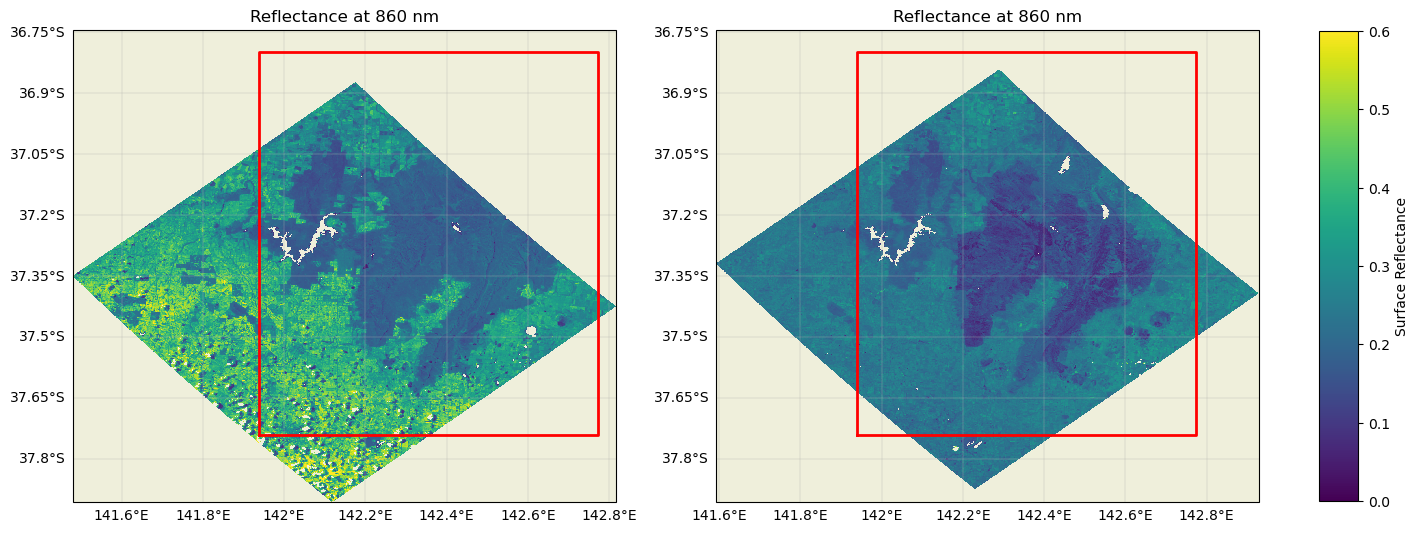

In [24]:
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=1)
im = emit_pre["reflectance"].sel(wavelengths=860, 
                                 method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6,
                                                        add_colorbar=False)
emit_post["reflectance"].sel(wavelengths=860, 
                             method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, 
                                                    add_colorbar=False)

plot_features(ax.flatten())
bbox = [141.9385, -37.74163, 142.77324, -36.79961]

cax = fig.add_axes([1.0025, 0.03, 0.03, 0.94]) 
fig.colorbar(im, cax=cax, label="Surface Reflectance")

# Plot bbox as a closed polygon
ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())
ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")   

plt.show()

Our EMIT data now match up to a physical location in space for each day of data, and can be used together in calculations later on. Let's make sure the same is true for PACE. 

### 3. Gridding PACE OCI Data
The `pace_tools` module provides a suite of functions for working with PACE OCI data, similar to the `emit_tools` module. We'll use the `open_l2` and `mask_ds` functions to accomplish the same steps for PACE as we did above with EMIT, with the key difference that the PACE data will not be gridded directly after opening the file. 

The PACE data again do not include a GLT, and so we will use their included 2D `latitude` and `longitude` arrays to perform the gridding. Due to aspects of `rasterio` and `rioxarray`, the packages we'll use to grid PACE data, as well as the fact that PACE's quality masks are included in the same L2 files as the reflectance data, all the masking must be done prior to the gridding step. Note that we are using the same `oci_pre` and `oci_post` variable names to denote the pre-fire and post-fire granules from PACE OCI, as we did with EMIT.

In [8]:
oci_pre = pace.open_l2(oci_paths[0])
oci_post = pace.open_l2(oci_paths[1])

oci_pre

<xarray.Dataset> Size: 1GB
Dimensions:        (number_of_lines: 1709, pixels_per_line: 1272,
                    wavelength_3d: 122)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 976B 346.0 351.0 ... 2.258e+03
    longitude      (number_of_lines, pixels_per_line) float32 9MB ...
    latitude       (number_of_lines, pixels_per_line) float32 9MB ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Data variables:
    rhos           (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
    l2_flags       (number_of_lines, pixels_per_line) int32 9MB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data SFREFL
    product_name:                      PACE_OCI.20241114T035224.L2.SFREFL.V3_...
    processing_version:                3.1
    history:                           l2gen par=/data15/sdpsoper/vdc/vpu14/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                126.49707
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0216763019561768
    geospatial_bounds:                 POLYGON ((155.81805 -32.45467, 126.497...

We can see that we have a dataset containing two variables: `rhos`, which are the surface reflectances for OCI, and `l2_flags`, which contain any masking information we may need. To mask the OCI data, all we need to know are the name(s) of the flags we want to use, and the `cf_xarray` package, which allows us to make use of those flags. For this example, we'll mask out clouds and water within the OCI scene using the "CLDICE" flag and the reverse of the "LAND" flag. A list of all possible flags can be found [on the Oceancolor Website](https://oceancolor.gsfc.nasa.gov/resources/atbd/ocl2flags/) (remember, PACE's home DAAC is the Ocean Biology DAAC! But make a good ocean color sensor and you make a great land sensor as well). 

In [9]:
oci_pre = pace.mask_ds(oci_pre, flag=["CLDICE","LAND"], reverse=[False,True])
oci_post = pace.mask_ds(oci_post, flag=["CLDICE","LAND"], reverse=[False,True])

CLDICE mask applied
LAND mask applied
CLDICE mask applied
LAND mask applied


Now that the cloud and water masks are applied, we can grid the data. The `grid_data` function uses the 2D latitude and longitude arrays in the OCI reflectance dataset, a user-supplied resolution, and a coordinate reference system (CRS) to align the data onto a defined grid. Technically, you could tell the function to use any resolution, even one finer than the resolution at which the satellite collects data, and it would give you an output dataset. However, you want to make sure whatever parameters are passed to the function make sense for your analysis. 

In this case, we'll use 0.015 degrees (~1.67 km at the equator), a resolution that is approximately the resolution of PACE OCI data at nadir (taking into account its wide swath). A deeper dive into this gridding method can be found on OB.DAAC's [Help Hub](https://nasa.github.io/oceandata-notebooks/).

In [10]:
resolution = (0.015, 0.015)

oci_pre = pace.grid_data(oci_pre, resolution=resolution)
oci_post = pace.grid_data(oci_post, resolution=resolution)

We can make the same plot as EMIT's above to see what the gridded OCI data look like:

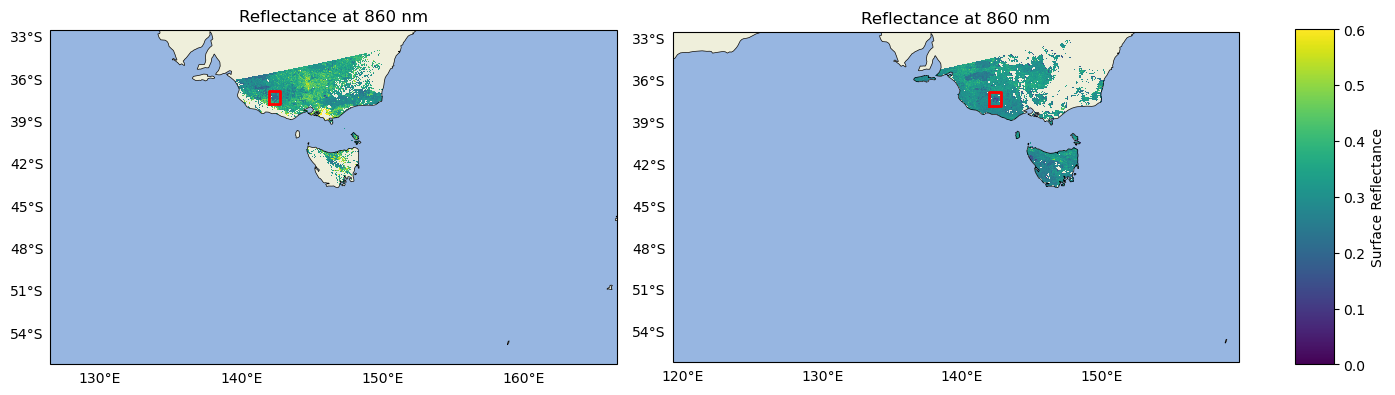

In [23]:
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout(pad=4)
oci_pre["rhos"].sel(wavelength_3d=860, 
                    method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6, add_colorbar=False)
im = oci_post["rhos"].sel(wavelength_3d=860, 
                          method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, add_colorbar=False)

plot_features(ax.flatten(), gridline_alpha=0)

cax = fig.add_axes([1, 0.165, 0.03, 0.67]) 
fig.colorbar(im, cax=cax, label='Surface Reflectance')

ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())
ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())  

ax[0].set_title("Reflectance at 860 nm")
ax[1].set_title("Reflectance at 860 nm")

plt.show()

Clearly, OCI covers a much wider area than EMIT does (but of course at a much coarser resolution). As seen with the red bounding box in the images above, our region of interest (ROI) is much smaller than a full OCI granule, and doesn't cover a full EMIT granule either, so let's subset our gridded EMIT and PACE data (which will also shrink these pretty large datasets and make them more memory-manageable).

In [12]:
oci_pre_sub = oci_pre.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
oci_post_sub = oci_post.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})

emit_pre_sub = emit_pre.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
emit_post_sub = emit_post.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})

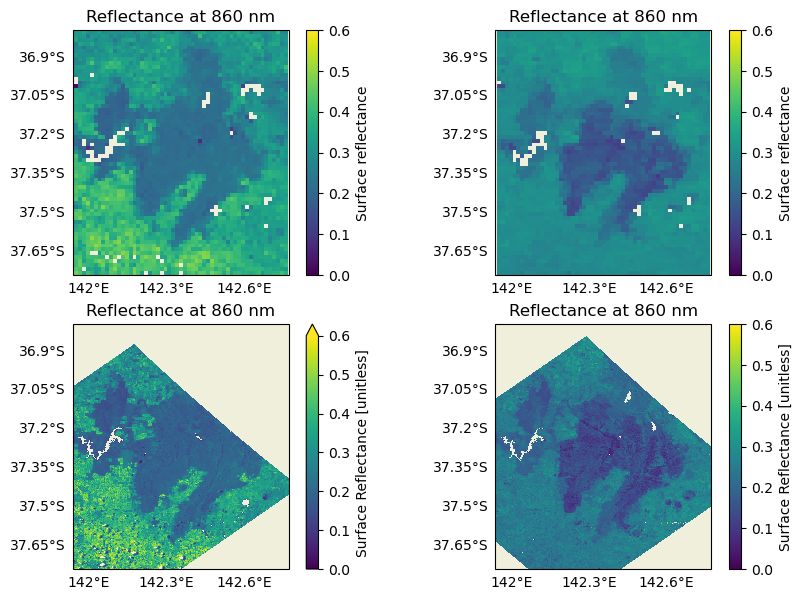

In [29]:
fig, ax = plt.subplots(2,2, figsize=(10,7),sharey=True, sharex=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
oci_pre_sub["rhos"].sel(wavelength_3d=860, 
                        method="nearest").plot(ax=ax[0][0],vmin=0, vmax=0.6)
ax[0][0].set_title("Reflectance at 860 nm")
oci_post_sub["rhos"].sel(wavelength_3d=860, 
                         method="nearest").plot(ax=ax[0][1],vmin=0, vmax=0.6)
ax[0][1].set_title("Reflectance at 860 nm")
emit_pre_sub["reflectance"].sel(wavelengths=860, 
                                method="nearest").plot(ax=ax[1][0],vmin=0, vmax=0.6)
ax[1][0].set_title("Reflectance at 860 nm")
emit_post_sub["reflectance"].sel(wavelengths=860, 
                                 method="nearest").plot(ax=ax[1][1],vmin=0, vmax=0.6)
ax[1][1].set_title("Reflectance at 860 nm")
plot_features(ax.flatten(), gridline_alpha=0)
plt.show()

In addition to a spatial subset, these datasets can be subset to include only the necessary wavelengths for the Normalized Burn Ratio (NBR) analysis that is the focus of the third tutorial in this series. NBR uses the NIR and SWIR to track changes in vegetation, so we can again use `xarray`'s `.sel()` functionality to grab only these bands. 

In [14]:
oci_pre_sub = oci_pre_sub.sel({"wavelength_3d":[870, 2131]}, method="nearest")
oci_post_sub = oci_post_sub.sel({"wavelength_3d":[870, 2131]}, method="nearest")

emit_pre_sub = emit_pre_sub.sel({"wavelengths":[870, 2131]}, method="nearest")
emit_post_sub = emit_post_sub.sel({"wavelengths":[870, 2131]}, method="nearest")

Let's export our datasets so we can continue working with them without repeating these steps each time.

In [15]:
oci_pre_sub.to_netcdf("emit_pace/subset_data/oci_prefire.nc")
oci_post_sub.to_netcdf("emit_pace/subset_data/oci_postfire.nc")

emit_pre_sub.to_netcdf("emit_pace/subset_data/emit_prefire.nc")
emit_post_sub.to_netcdf("emit_pace/subset_data/emit_postfire.nc")

### 4. Aligning PACE and EMIT Grids 
The case study example in `03_NBR_with_PACE_EMIT.ipynb` doesn't require PACE and EMIT to be on the same grid as we are going to illustrate the complimentary nature of the instruments' temporal, spatial, and spectral resolutions. However, there may be times when you want to align grids (and therefore, resolutions) between these two instruments. We'll take our pre-fire subsets from OCI and EMIT and demonstrate how to align their grids below using a modified version of the `grid_data` function in the `pace_tools` module. 

If we zoom in close enough, we can see the difference in pixel size between PACE and EMIT:

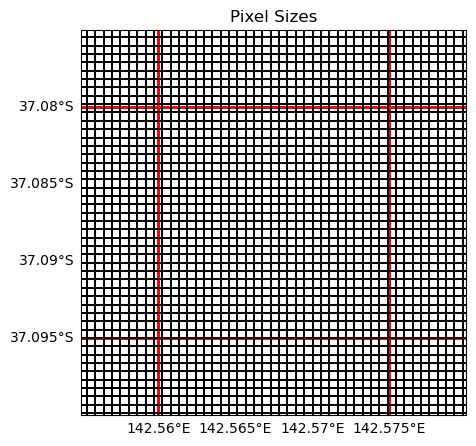

In [16]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
oci_pre_sub.rhos.sel({"wavelength_3d":860}, method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", transform=ccrs.PlateCarree(),linewidth=2, edgecolors="red", add_colorbar=False)
emit_pre_sub.reflectance.sel({"wavelengths":860}, method="nearest").plot(vmin=0, vmax=1, cmap="viridis", transform=ccrs.PlateCarree(),  linewidth=0.05, edgecolors="k", add_colorbar=False, alpha=1)
ax.set_extent([142.555, 142.58, -37.1, -37.075])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Sizes")
plt.show()

The red outlines above show the boundaries for PACE pixels and the grey lines similarly delineate EMIT pixels within the same region. The EMIT resolution is significantly finer at the cost of more sparse observations. Conversely, a single pixel is coarse compared to EMIT, which allows for very frequent overpass times. 

Additionally, we can see that the EMIT and PACE grids are not spatially aligned. This misalignment poses the same issue as when we were talking about intra-sensor comparisons, with the added complexity of the pixel size differences. We can use the `grid_data` function to regrid and resample either dataset, coarsening EMIT to match PACE's resolution, or sharpening (interpolating) PACE onto EMIT's finer grid. 

<div class="alert alert-warning" role="alert">

It is important to note that sharpening the data does not increase the information content of the data.

</div>

In other words, this approach will just be duplicating existing values to fill a larger quantity of pixels covering the same spatial extent. This sharpening method is still useful, and often employed to prepare a consistent grid for analysis when the goal is to preserve fine-resolution details from the higher resolution dataset. A coarsening approach is often selected when the goal is to reduce noise in high resolution imagery or reduce file sizes for large scale regional and global studies.

Since we want to retain the features resolved by EMIT data, let's regrid the PACE data to that finer resolution and see what the above means practically. We'll use the Affine transform from the EMIT data to grab its spatial resolution, and we'll use it's CRS as our destination CRS. Note that both of these datasets use EPSG 4326, so the defaults in the `grid_data` function would be fine, but we'll set them explicitly to be thorough.

In [17]:
oci_finer = pace.grid_data(src=oci_pre_sub, 
                           dst_transform=emit_pre_sub.rio.transform())

We can plot the pixel boundaries again to check that our granules are at the same resolution now.

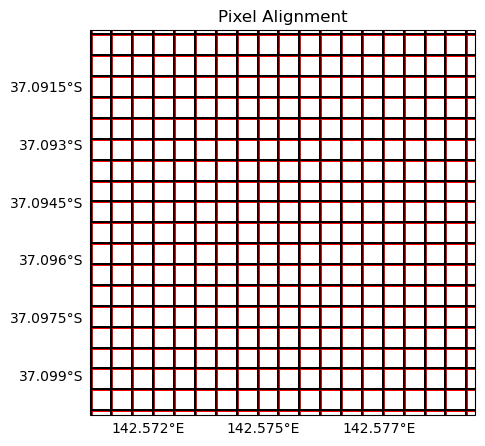

In [21]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
oci_finer.rhos.sel({"wavelength_3d":860}, 
                   method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", 
                                          transform=ccrs.PlateCarree(), 
                                          linewidth=2, edgecolors="red", 
                                          add_colorbar=False)
emit_pre_sub.reflectance.sel({"wavelengths":860}, 
                             method="nearest").plot(vmin=0, vmax=1, 
                                                    transform=ccrs.PlateCarree(),  
                                                    linewidth=0.05, edgecolors="k", 
                                                    add_colorbar=False)

ax.set_extent([142.57, 142.58, -37.1,  -37.09])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Alignment")
plt.show()

We can see the pixels are aligned, which would allow for spectral comparisons between the two datasets. A similar method could be used to coarsen the EMIT data to PACE's resolution. 

<div class="alert alert-info" role="alert">

You have completed the second notebook in the PACE+EMIT series. We suggest moving on to the third notebook, `03_NBR_with_PACE_EMIT`, which uses the data we aligned here to conduct a burn analysis on wildfires which occurred in Grampians National Park, Victoria, Australia in 2024-2025.

</div>